In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 下載台積電股價數據
ticker = yf.Ticker("2330.TW")
df = ticker.history(period="1y")
df = df[["Close"]]

In [3]:
# 數據預處理
def prepare_data(data, look_back=5):
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(len(scaled_data) - look_back):
        X.append(scaled_data[i : i + look_back].flatten())
        y.append(scaled_data[i + look_back][0])

    return np.array(X), np.array(y), scaler

In [4]:
# 神經網絡模型
class ANN(nn.Module):
    def __init__(self, input_dim):
        super(ANN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 25),
            nn.ReLU(),
            nn.Linear(25, 1),
        )

    def forward(self, x):
        return self.layers(x)


class SimpleRNN_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleRNN_Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.rnn = nn.RNN(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 重新塑造輸入張量為 (batch_size, sequence_length, input_dim)
        x = x.view(x.size(0), -1, 1)
        r_out, _ = self.rnn(x)
        predictions = self.fc(r_out[:, -1, :])
        return predictions


class LSTM_Model(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTM_Model, self).__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 重新塑造輸入張量為 (batch_size, sequence_length, input_dim)
        x = x.view(x.size(0), -1, 1)
        lstm_out, _ = self.lstm(x)
        predictions = self.fc(lstm_out[:, -1, :])
        return predictions

In [5]:
# 訓練函數
def train_model(model, X_train, y_train, epochs=100, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 轉換為PyTorch張量
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train)

    losses = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_tensor)
        loss = criterion(outputs.squeeze(), y_train_tensor)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    return losses

In [6]:
# 主執行程序
X, y, scaler = prepare_data(df["Close"].values.reshape(-1, 1))

# 切分訓練和測試數據
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ANN模型
ann_model = ANN(X_train.shape[1])
ann_losses = train_model(ann_model, X_train, y_train)
print("ANN:", ann_model)

# LSTM模型
lstm_model = LSTM_Model(input_dim=1, hidden_dim=50)
lstm_losses = train_model(lstm_model, X_train, y_train)
print("LSTM:", lstm_model)

Epoch [1/100], Loss: 0.3204
Epoch [11/100], Loss: 0.0299
Epoch [21/100], Loss: 0.0149
Epoch [31/100], Loss: 0.0057
Epoch [41/100], Loss: 0.0023
Epoch [51/100], Loss: 0.0017
Epoch [61/100], Loss: 0.0017
Epoch [71/100], Loss: 0.0014
Epoch [81/100], Loss: 0.0014
Epoch [91/100], Loss: 0.0014
ANN: ANN(
  (layers): Sequential(
    (0): Linear(in_features=5, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=25, bias=True)
    (3): ReLU()
    (4): Linear(in_features=25, out_features=1, bias=True)
  )
)
Epoch [1/100], Loss: 0.1773
Epoch [11/100], Loss: 0.0259
Epoch [21/100], Loss: 0.0132
Epoch [31/100], Loss: 0.0092
Epoch [41/100], Loss: 0.0062
Epoch [51/100], Loss: 0.0020
Epoch [61/100], Loss: 0.0017
Epoch [71/100], Loss: 0.0011
Epoch [81/100], Loss: 0.0012
Epoch [91/100], Loss: 0.0011
LSTM: LSTM_Model(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [7]:
# 評估模型
def evaluate_model(model, X_test, y_test, scaler, is_lstm=False):
    model.eval()
    X_test_tensor = torch.FloatTensor(X_test)

    with torch.no_grad():
        test_pred = model(X_test_tensor).numpy()

    test_pred_inv = scaler.inverse_transform(test_pred)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    mse = mean_squared_error(y_test_inv, test_pred_inv)
    mae = mean_absolute_error(y_test_inv, test_pred_inv)

    return mse, mae, test_pred_inv, y_test_inv

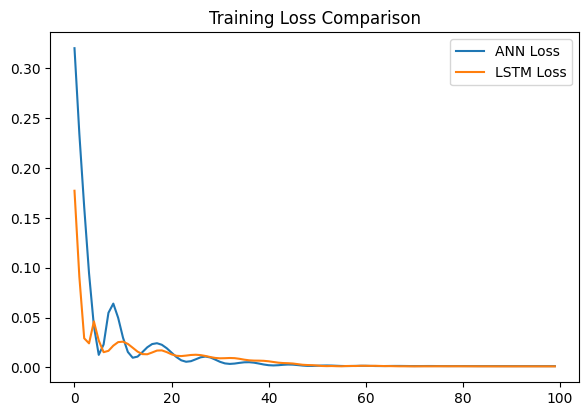

In [8]:
# 計算ANN評估指標
ann_mse, ann_mae, ann_pred, ann_true = evaluate_model(ann_model, X_test, y_test, scaler)

# 計算LSTM評估指標
lstm_mse, lstm_mae, lstm_pred, lstm_true = evaluate_model(
    lstm_model, X_test, y_test, scaler, is_lstm=True
)

# 繪製結果比較
plt.figure(figsize=(15, 10))

# 損失曲線
plt.subplot(2, 2, 1)
plt.plot(ann_losses, label="ANN Loss")
plt.plot(lstm_losses, label="LSTM Loss")
plt.title("Training Loss Comparison")
plt.legend()

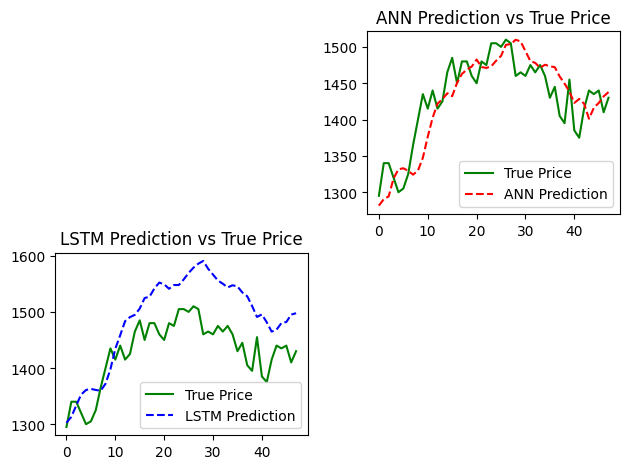


ANN 模型評估:
均方誤差 (MSE): 1097.1937577531983
平均絕對誤差 (MAE): 26.37148030598958

LSTM 模型評估:
均方誤差 (MSE): 5079.938042938092
平均絕對誤差 (MAE): 63.15375773111981


In [9]:
# 預測結果比較
plt.subplot(2, 2, 2)
plt.plot(ann_true, label="True Price", color="green")
plt.plot(ann_pred, label="ANN Prediction", color="red", linestyle="--")
plt.title("ANN Prediction vs True Price")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(lstm_true, label="True Price", color="green")
plt.plot(lstm_pred, label="LSTM Prediction", color="blue", linestyle="--")
plt.title("LSTM Prediction vs True Price")
plt.legend()

plt.tight_layout()
plt.show()

# 列印模型評估指標
print("\nANN 模型評估:")
print(f"均方誤差 (MSE): {ann_mse}")
print(f"平均絕對誤差 (MAE): {ann_mae}")

print("\nLSTM 模型評估:")
print(f"均方誤差 (MSE): {lstm_mse}")
print(f"平均絕對誤差 (MAE): {lstm_mae}")